<a href="https://colab.research.google.com/github/rafiq9090/Learning-AI/blob/main/Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import yaml
from ultralytics import YOLO


dataset_path = '/content/Construction-Site-Safety-24'


data_config = {
    'train': f'{dataset_path}/train/images',
    'val': f'{dataset_path}/valid/images',
    'test': f'{dataset_path}/test/images',
    'nc': 10,
    'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
}

with open('local_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("New local_data.yaml created!")


model = YOLO('yolov8n.pt')
model.train(
    data='local_data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    name='safety_model_fix',
    device=0
)

ModuleNotFoundError: No module named 'ultralytics'

Extracting /content/Construction-Site-Safety-24/roboflow.zip to /content/Construction-Site-Safety-24...


BadZipFile: File is not a zip file

In [ ]:
import zipfile
import os


print(f"Verifying integrity of: {zip_file_path}")

if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            print("File is a valid zip archive. Contents:")
            zip_ref.printdir()
    except zipfile.BadZipFile:
        print("Error: The file is NOT a valid zip archive. It might be corrupted or incomplete.")
    except Exception as e:
        print(f"An unexpected error occurred while trying to open the zip file: {e}")
else:
    print(f"Error: The file {zip_file_path} does not exist. Please ensure the download completed successfully.")

Verifying integrity of: /content/Construction-Site-Safety-24/roboflow.zip
Error: The file is NOT a valid zip archive. It might be corrupted or incomplete.


In [ ]:
import os

if os.path.exists(zip_file_path):
    file_size = os.path.getsize(zip_file_path)
    print(f"File size of {zip_file_path}: {file_size} bytes")
    if file_size == 0:
        print("Warning: The zip file is empty.")
else:
    print(f"Error: The file {zip_file_path} does not exist.")

File size of /content/Construction-Site-Safety-24/roboflow.zip: 252 bytes


In [ ]:
import os
!rm -rf /content/Construction-Site-Safety-24
!mkdir -p /content/Construction-Site-Safety-24
%cd /content/Construction-Site-Safety-24


!curl -L "https://universe.roboflow.com/ds/8vUuUa9YFm?key=h4Z4hNsAk2Kfl892kSt4" > roboflow.zip && unzip roboflow.zip && rm roboflow.zip
%cd /content


/content/Construction-Site-Safety-24
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5441  100  5441    0     0  66205      0 --:--:-- --:--:-- --:--:-- 66353
Archive:  roboflow.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of roboflow.zip or
        roboflow.zip.zip, and cannot find roboflow.zip.ZIP, period.
/content


In [ ]:
!mkdir -p /content/Construction-Site-Safety-24
!unzip /content/roboflow.zip -d /content/Construction-Site-Safety-24

unzip:  cannot find or open /content/roboflow.zip, /content/roboflow.zip.zip or /content/roboflow.zip.ZIP.


In [2]:
!rm /content/roboflow.zip

rm: cannot remove '/content/roboflow.zip': No such file or directory


In [7]:
from requests.auth import extract_cookies_to_jar
from numpy import extract
import os
import zipfile # Added this line
!pip install roboflow
!pip install ultralytics
from roboflow import Roboflow
from ultralytics import YOLO

zip_file_path = '/content/construction-site-safety.v1i.yolov8.zip'
extract_path = '/content/dataset'

if os.path.exists(zip_file_path):

    print(f"Verifying integrity of: {zip_file_path}")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref: # Changed ZipExtFile to ZipFile
        print("File is a valid zip archive. Contents:")
        zip_ref.extractall(extract_path) # Added this line to extract the zip file contents
        print(f"Dataset extracted to {extract_path}")

        model = YOLO('yolov8n.pt')

        model.train(
            data=f'{extract_path}/data.yaml',
            epochs=25,
            imgsz=640,
            batch=16,
            name='helmet_safety_model',
            device=0
        )
else:
  print(f"Error: The file {zip_file_path} does not exist. Please ensure the download completed successfully.")

Verifying integrity of: /content/construction-site-safety.v1i.yolov8.zip
File is a valid zip archive. Contents:
Dataset extracted to /content/dataset
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum

In [8]:
from google.colab import files
files.download('/content/runs/detect/helmet_safety_model-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

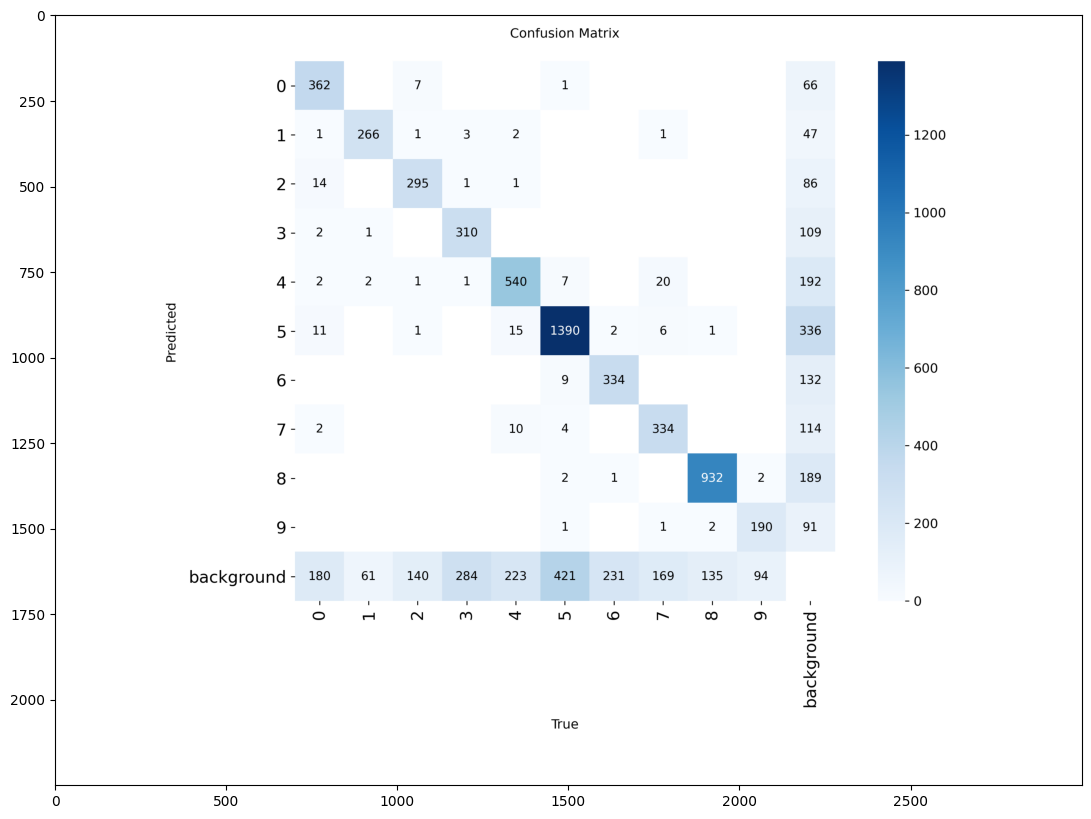

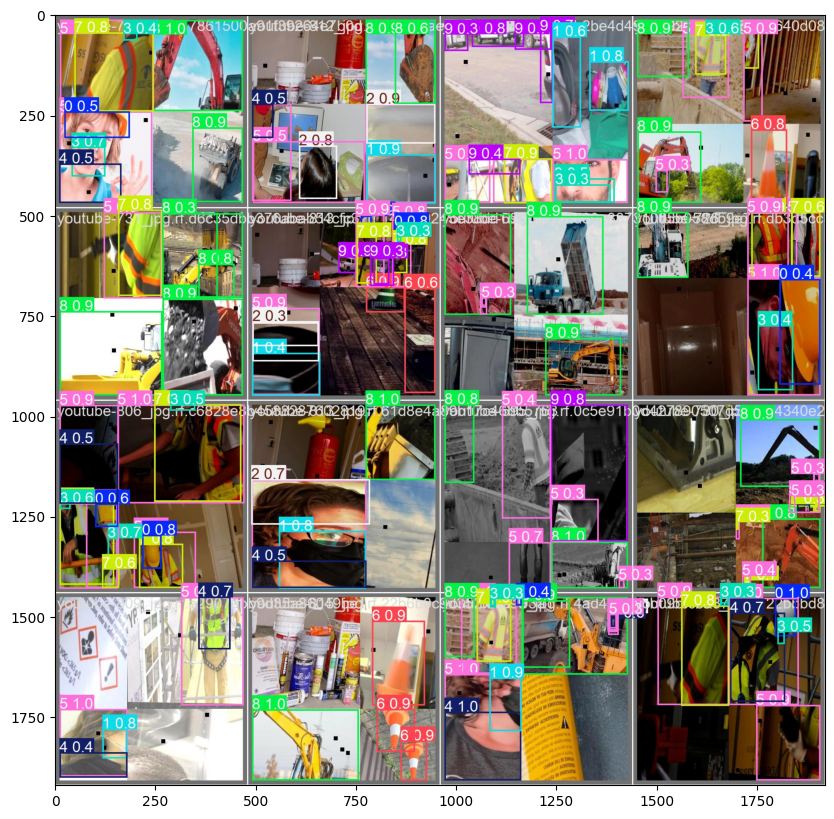

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/content/runs/detect/helmet_safety_model-2/confusion_matrix.png')
plt.figure(figsize=(15,10))
plt.imshow(img)
plt.show()


imag_val = mpimg.imread('/content/runs/detect/helmet_safety_model-2/val_batch0_pred.jpg')
plt.figure(figsize=(15,10))
plt.imshow(imag_val)
plt.show()

Test


image 1/554 /content/dataset/valid/images/-1079-_png_jpg.rf.406400dfdb33173a86efa026a2e3cdb0.jpg: 640x640 1 0, 2 4s, 3 5s, 8.8ms
image 2/554 /content/dataset/valid/images/-1670-_png_jpg.rf.aca9d2bcc9fa3e711661905965754b32.jpg: 640x640 2 0s, 1 2, 2 4s, 2 5s, 6 8s, 7.2ms
image 3/554 /content/dataset/valid/images/-1680-_png_jpg.rf.035b811f766243893ac15e340fab0a4d.jpg: 640x640 1 1, 1 2, 3 5s, 1 8, 7.2ms
image 4/554 /content/dataset/valid/images/-1680-_png_jpg.rf.a819487456205e012386bd6a78afb64d.jpg: 640x640 2 0s, 2 3s, 2 4s, 4 5s, 2 8s, 7.2ms
image 5/554 /content/dataset/valid/images/-1975-_png_jpg.rf.926d5a97301515a662164e980ed7f185.jpg: 640x640 4 2s, 2 3s, 3 4s, 5 5s, 4 8s, 10.0ms
image 6/554 /content/dataset/valid/images/-2297-_png_jpg.rf.79a0946ac7e7c61878b99b030d62ba3e.jpg: 640x640 2 0s, 2 3s, 2 4s, 4 5s, 1 7, 2 8s, 7.2ms
image 7/554 /content/dataset/valid/images/-2297-_png_jpg.rf.cae0d86a2f4b081d822a46c5ccdc9b81.jpg: 640x640 1 1, 1 4, 2 5s, 1 7, 7.2ms
image 8/554 /content/dataset/va

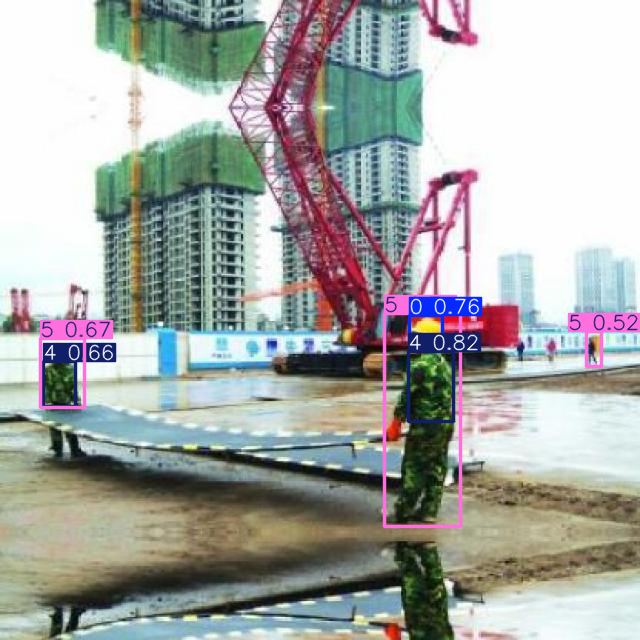

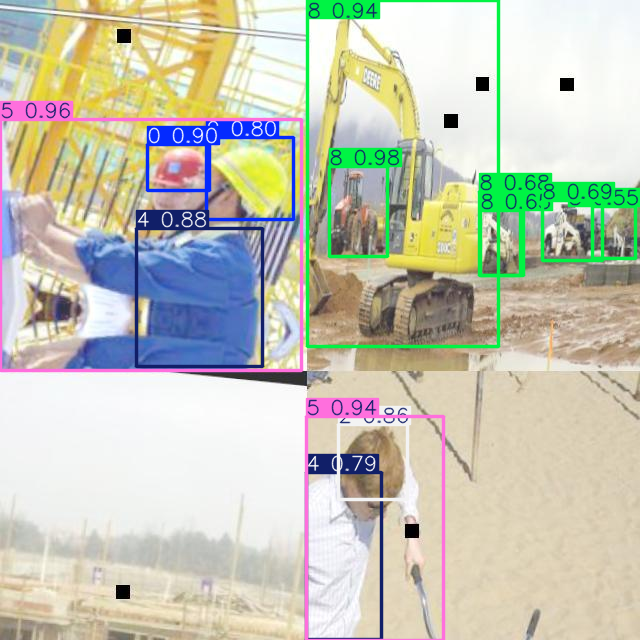

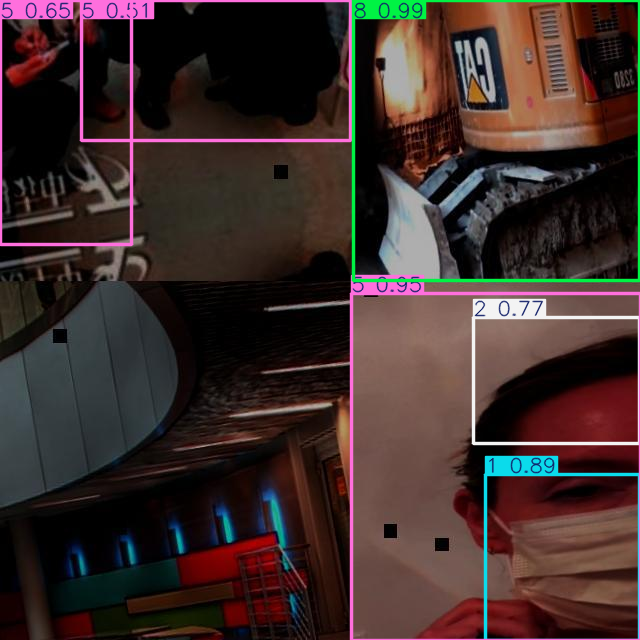

In [10]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('/content/runs/detect/helmet_safety_model-2/weights/best.pt')
results = model.predict(source='/content/dataset/valid/images', save=True, conf=0.5)

for result in results[:3]:
  res_plotted = result.plot()
  cv2_imshow(res_plotted)

In [12]:
!pip install yt-dlp

import os
video_url = 'https://www.youtube.com/watch?v=2vU281f6P50'
!yt-dlp -f 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4' --output "safety_test.mp4" "{video_url}"
print('download complete')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.2 MB/s eta 0:00:00
[youtube] Extracting URL: https://www.youtube.com/watch?v=2vU281f6P50
[youtube] 2vU281f6P50: Downloading webpage
[youtube] 2vU281f6P50: Downloading android vr player API JSON
ERROR: [youtube] 2vU281f6P50: Video unavailable
download complete


In [27]:
!curl -L -o safety_test.mp4 https://github.com/ultralytics/assets/releases/download/v0.0.0/test.mp4 || \
!wget -O safety_test.mp4 https://raw.githubusercontent.com/ultralytics/assets/main/yolov8/test.mp4

import os
if os.path.exists('safety_test.mp4'):
  print("download complete")
else:
  print("fa")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100     9  100     9    0     0     27      0 --:--:-- --:--:-- --:--:--    27
download complete


In [33]:
from torch._C import device
import os
video_path = '/content/my_test.mp4'

if os.path.exists(video_path):
    print("Video file exists.")
    !yolo predict model='/content/runs/detect/helmet_safety_model-2/weights/best.pt' \
    source='/content/my_test.mp4' \
    conf=0.25 \
    save=True \
    device=0
else:
    print("Video file does not exist.")

Video file exists.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

video 1/1 (frame 1/323) /content/my_test.mp4: 640x384 2 0s, 2 3s, 2 5s, 3 7s, 46.6ms
video 1/1 (frame 2/323) /content/my_test.mp4: 640x384 2 0s, 2 3s, 3 5s, 3 7s, 6.5ms
video 1/1 (frame 3/323) /content/my_test.mp4: 640x384 2 0s, 2 3s, 4 5s, 2 7s, 6.7ms
video 1/1 (frame 4/323) /content/my_test.mp4: 640x384 2 0s, 3 3s, 3 5s, 2 7s, 6.5ms
video 1/1 (frame 5/323) /content/my_test.mp4: 640x384 2 0s, 2 3s, 1 4, 4 5s, 1 7, 7.1ms
video 1/1 (frame 6/323) /content/my_test.mp4: 640x384 2 0s, 1 1, 2 3s, 2 4s, 2 5s, 7.2ms
video 1/1 (frame 7/323) /content/my_test.mp4: 640x384 2 0s, 2 3s, 2 5s, 2 7s, 7.8ms
video 1/1 (frame 8/323) /content/my_test.mp4: 640x384 2 0s, 1 3, 1 4, 2 5s, 2 7s, 6.7ms
video 1/1 (frame 9/323) /content/my_test.mp4: 640x384 2 0s, 1 3, 1 4, 4 5s, 1 7, 6.9ms
video 1/1 (frame 10/323) /content/my_test.mp

In [38]:
import os
import glob
from google.colab import files

search_path = "/content/runs/detect/predict*/*"
all_files = glob.glob(search_path)

video_extensions = ('.mp4', '.avi', '.mkv', '.mov')
found_videos = [f for f in all_files if f.lower().endswith(video_extensions)]

if found_videos:
    for video in found_videos:
        print(f" video is detected: {video}")
        print(f" {os.path.basename(video)} downlaod start")
        files.download(video)
else:
    print("")
    !ls -R /content/runs/detect/

 video is detected: /content/runs/detect/predict-3/my_test.avi
 my_test.avi downlaod start


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 video is detected: /content/runs/detect/predict-4/my_test.avi
 my_test.avi downlaod start


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>